In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

covid_df = pd.read_csv("covid19_Confirmed_dataset.csv")
happiness_df = pd.read_csv("worldwide_happiness_report.csv")

print("COVID Dataset Shape:", covid_df.shape)
print("Happiness Dataset Shape:", happiness_df.shape)

covid_df.head()


COVID Dataset Shape: (266, 104)
Happiness Dataset Shape: (156, 9)


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20
0,NaN,Afghanistan,33.0000,65.0000,0,0,0,0,0,0,...,1092,1176,1279,1351,1463,1531,1703,1828,1939,2171
1,NaN,Albania,41.1533,20.1683,0,0,0,0,0,0,...,609,634,663,678,712,726,736,750,766,773
2,NaN,Algeria,28.0339,1.6596,0,0,0,0,0,0,...,2811,2910,3007,3127,3256,3382,3517,3649,3848,4006
3,NaN,Andorra,42.5063,1.5218,0,0,0,0,0,0,...,717,723,723,731,738,738,743,743,743,745
4,NaN,Angola,-11.2027,17.8739,0,0,0,0,0,0,...,24,25,25,25,25,26,27,27,27,27


In [19]:
covid_df = covid_df.drop(["Province/State", "Lat", "Long"], axis=1)

covid_df.head()


,Country/Region,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,...,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20
0,Afghanistan,0,0,0,0,0,0,0,0,0,...,1092,1176,1279,1351,1463,1531,1703,1828,1939,2171
1,Albania,0,0,0,0,0,0,0,0,0,...,609,634,663,678,712,726,736,750,766,773
2,Algeria,0,0,0,0,0,0,0,0,0,...,2811,2910,3007,3127,3256,3382,3517,3649,3848,4006
3,Andorra,0,0,0,0,0,0,0,0,0,...,717,723,723,731,738,738,743,743,743,745
4,Angola,0,0,0,0,0,0,0,0,0,...,24,25,25,25,25,26,27,27,27,27


In [20]:
covid_agg = covid_df.groupby("Country/Region").sum()

covid_agg.head()


,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,1092,1176,1279,1351,1463,1531,1703,1828,1939,2171
Albania,0,0,0,0,0,0,0,0,0,0,...,609,634,663,678,712,726,736,750,766,773
Algeria,0,0,0,0,0,0,0,0,0,0,...,2811,2910,3007,3127,3256,3382,3517,3649,3848,4006
Andorra,0,0,0,0,0,0,0,0,0,0,...,717,723,723,731,738,738,743,743,743,745
Angola,0,0,0,0,0,0,0,0,0,0,...,24,25,25,25,25,26,27,27,27,27


In [21]:
covid_agg["Max Infection Rate"] = covid_agg.max(axis=1)

covid_data = covid_agg[["Max Infection Rate"]]

covid_data.head()


,Max Infection Rate
Country/Region,
Afghanistan,2171
Albania,773
Algeria,4006
Andorra,745
Angola,27


In [26]:
# Keep required columns
happiness_df = happiness_df[[
    "Country or region",
    "Score",
    "GDP per capita",
    "Social support",
    "Healthy life expectancy",
    "Freedom to make life choices"
]]

# Rename country column to match COVID dataset
happiness_df = happiness_df.rename(columns={
    "Country or region": "Country/Region"
})

# Set index
happiness_df.set_index("Country/Region", inplace=True)

happiness_df.head()


,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
Country/Region,,,,,
Finland,7.769,1.340,1.587,0.986,0.596
Denmark,7.600,1.383,1.573,0.996,0.592
Norway,7.554,1.488,1.582,1.028,0.603
Iceland,7.494,1.380,1.624,1.026,0.591
Netherlands,7.488,1.396,1.522,0.999,0.557


In [27]:
data = covid_data.join(happiness_df, how="inner")
data.head()


,Max Infection Rate,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
Country/Region,,,,,,
Afghanistan,2171,3.203,0.350,0.517,0.361,0.000
Albania,773,4.719,0.947,0.848,0.874,0.383
Algeria,4006,5.211,1.002,1.160,0.785,0.086
Argentina,4428,6.086,1.092,1.432,0.881,0.471
Armenia,2066,4.559,0.850,1.055,0.815,0.283


In [28]:
correlation = data.corr()
correlation


,Max Infection Rate,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
Max Infection Rate,1.000000,0.285719,0.328993,0.241542,0.341925,0.029729
Score,0.285719,1.000000,0.793847,0.788591,0.799893,0.587007
GDP per capita,0.328993,0.793847,1.000000,0.759468,0.863062,0.394603
Social support,0.241542,0.788591,0.759468,1.000000,0.765286,0.456246
Healthy life expectancy,0.341925,0.799893,0.863062,0.765286,1.000000,0.427892
Freedom to make life choices,0.029729,0.587007,0.394603,0.456246,0.427892,1.000000


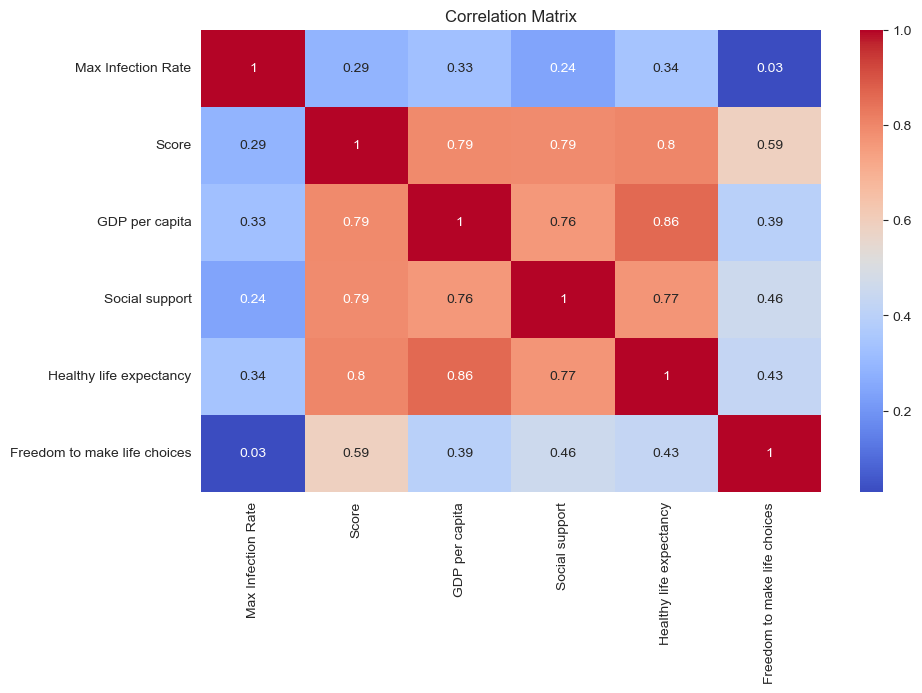

In [29]:
plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


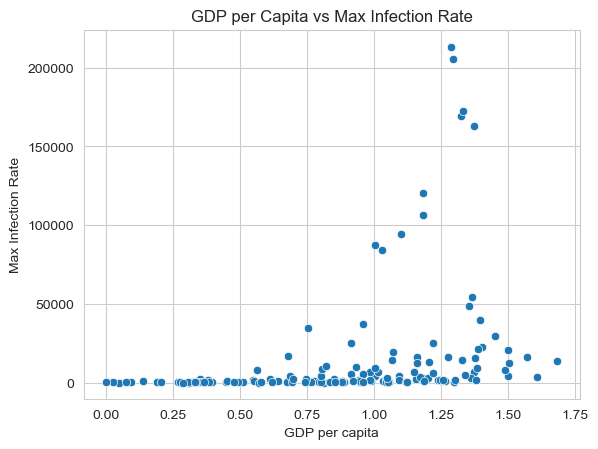

In [30]:
sns.scatterplot(x=data["GDP per capita"], y=data["Max Infection Rate"])
plt.title("GDP per Capita vs Max Infection Rate")
plt.show()

